In [1]:
#   PHASE 2A — AI CONTROL LOOP SIMULATOR                          
#   PID Controller + PPO RL Agent + Adversarial Injection         
#   Justifies "AI-Controlled CPS" in the project title           

!pip install stable-baselines3 gymnasium scikit-learn pandas numpy \
             matplotlib seaborn scipy -q

import os, pickle, warnings, json
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn            as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics       import mean_squared_error

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'figure.dpi'       : 120,
})

# ── Paths ────────────────────────────────────────────────────────
P1  = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase1/processed'
P2  = '/kaggle/input/notebooks/jaytalwar2005/ctmas-phase2/processed'
OUT = '/kaggle/working/'

for d in [f'{OUT}/figures', f'{OUT}/processed', f'{OUT}/models']:
    os.makedirs(d, exist_ok=True)

# ── Verify inputs ────────────────────────────────────────────────
print('Verifying input files...')
checks = [
    (f'{P1}/swat_clean.csv',          'Phase1: swat_clean.csv'),
    (f'{P1}/layer_map.json',           'Phase1: layer_map.json'),
    (f'{P1}/phase1_config.json',       'Phase1: phase1_config.json'),
    (f'{P2}/layer_physical_train.csv', 'Phase2: physical train'),
    (f'{P2}/layer_control_train.csv',  'Phase2: control train'),
    (f'{P2}/layer_scalers.pkl',        'Phase2: layer scalers'),
    (f'{P2}/phase2_config.json',       'Phase2: phase2_config'),
]
all_ok = True
for path, name in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024**2 if exists else 0
    status = 'Yes' if exists else 'No MISSING'
    print(f'  {status}  {name:<35}  {size:6.1f} MB')
    if not exists:
        all_ok = False

print(f'\n  All files present: {"YES" if all_ok else "NO — check paths"}')
print('\n Phase 2A setup complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.3 MB/s eta 0:00:00
Verifying input files...
  Yes  Phase1: swat_clean.csv                281.4 MB
  Yes  Phase1: layer_map.json                  0.0 MB
  Yes  Phase1: phase1_config.json              0.0 MB
  Yes  Phase2: physical train               1373.4 MB
  Yes  Phase2: control train                 349.2 MB
  Yes  Phase2: layer scalers                   0.0 MB
  Yes  Phase2: phase2_config                   0.0 MB

  All files present: YES

 Phase 2A setup complete


In [2]:
#  CELL 2 — Load data from Phase 1 and Phase 2                   

print('Loading data...')

# Master dataset from Phase 1
df = pd.read_csv(f'{P1}/swat_clean.csv', low_memory=False)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
print(f'  Yes swat_clean.csv     → {df.shape[0]:,} rows × {df.shape[1]} cols')

# Layer map
with open(f'{P1}/layer_map.json') as f:
    LAYER_MAP = json.load(f)

# Phase 1 config
with open(f'{P1}/phase1_config.json') as f:
    P1_CONFIG = json.load(f)

# Phase 2 scalers
with open(f'{P2}/layer_scalers.pkl', 'rb') as f:
    layer_scalers = pickle.load(f)

# Split normal vs attack
df_normal = df[df['binary_label'] == 0].copy().reset_index(drop=True)
df_attack  = df[df['binary_label'] == 1].copy().reset_index(drop=True)

print(f'   Normal rows : {len(df_normal):,}')
print(f'   Attack rows : {len(df_attack):,}')

# Key sensors for control loop simulation
# LIT101 = water level tank 1 (primary controlled variable)
# MV101  = motorised valve (primary actuator)
# P101   = pump (secondary actuator)
# LIT301 = water level tank 3 (secondary controlled variable)
# LIT401 = water level tank 4 (tertiary controlled variable)

CONTROL_SENSORS   = ['LIT101', 'LIT301', 'LIT401',
                      'FIT101', 'FIT201', 'FIT301']
CONTROL_ACTUATORS = ['MV101', 'P101', 'P102',
                     'MV201', 'MV301', 'P301']

# Setpoints (normal operating targets from SWaT documentation)
SETPOINTS = {
    'LIT101' : 600.0,   # mm — raw water tank target level
    'LIT301' : 900.0,   # mm — UF tank target level
    'LIT401' : 800.0,   # mm — RO tank target level
    'FIT101' : 1.85,    # L/s — inlet flow target
    'FIT201' : 1.85,    # L/s — stage 2 flow target
    'FIT301' : 1.85,    # L/s — stage 3 flow target
}

print(f'\n Control sensors   : {CONTROL_SENSORS}')
print(f' Control actuators : {CONTROL_ACTUATORS}')
print(f' Setpoints         : {SETPOINTS}')

Loading data...
  Yes swat_clean.csv     → 944,919 rows × 55 cols
   Normal rows : 890,298
   Attack rows : 54,621

 Control sensors   : ['LIT101', 'LIT301', 'LIT401', 'FIT101', 'FIT201', 'FIT301']
 Control actuators : ['MV101', 'P101', 'P102', 'MV201', 'MV301', 'P301']
 Setpoints         : {'LIT101': 600.0, 'LIT301': 900.0, 'LIT401': 800.0, 'FIT101': 1.85, 'FIT201': 1.85, 'FIT301': 1.85}


In [3]:
#   CELL 3 — PID Controller                                       
#   Simulates what a real PLC does:                               
#   reads sensor value → computes error → outputs actuator command 

class PIDController:
    """
    Proportional-Integral-Derivative controller.
    Models the control logic of a SWaT PLC.

    Given a sensor reading and setpoint, outputs an actuator command
    (valve open/close, pump on/off) to minimise the error.
    """

    def __init__(self, kp=1.2, ki=0.1, kd=0.05,
                 output_min=0.0, output_max=2.0, dt=1.0):
        self.kp         = kp           # Proportional gain
        self.ki         = ki           # Integral gain
        self.kd         = kd           # Derivative gain
        self.output_min = output_min   # Min actuator command (valve closed)
        self.output_max = output_max   # Max actuator command (valve fully open)
        self.dt         = dt           # Sampling time (1 second in SWaT)

        # Internal state
        self._integral   = 0.0
        self._prev_error = 0.0
        self._history    = []

    def reset(self):
        self._integral   = 0.0
        self._prev_error = 0.0
        self._history    = []

    def step(self, measurement, setpoint):
        """
        One PID step.
        Args:
            measurement: current sensor reading
            setpoint:    target value
        Returns:
            control_output: actuator command [output_min, output_max]
            error:          current error (setpoint - measurement)
        """
        error = setpoint - measurement

        # Proportional term
        p_term = self.kp * error

        # Integral term (with anti-windup clipping)
        self._integral += error * self.dt
        self._integral  = np.clip(self._integral, -100, 100)
        i_term          = self.ki * self._integral

        # Derivative term
        d_term          = self.kd * (error - self._prev_error) / self.dt
        self._prev_error = error

        # Total output
        output = p_term + i_term + d_term
        output = np.clip(output, self.output_min, self.output_max)

        self._history.append({
            'error'   : error,
            'p_term'  : p_term,
            'i_term'  : i_term,
            'd_term'  : d_term,
            'output'  : output,
        })

        return output, error

    def run_on_series(self, measurements, setpoint):
        """Run PID on a full time series. Returns control outputs and errors."""
        self.reset()
        outputs = []
        errors  = []
        for m in measurements:
            out, err = self.step(float(m), float(setpoint))
            outputs.append(out)
            errors.append(err)
        return np.array(outputs), np.array(errors)

    def get_history_df(self):
        return pd.DataFrame(self._history)


# ── Instantiate PID controllers — one per controlled variable ────
pid_controllers = {
    'LIT101': PIDController(kp=1.5, ki=0.08, kd=0.05),
    'LIT301': PIDController(kp=1.2, ki=0.10, kd=0.04),
    'LIT401': PIDController(kp=1.3, ki=0.09, kd=0.05),
    'FIT101': PIDController(kp=2.0, ki=0.15, kd=0.03),
    'FIT201': PIDController(kp=2.0, ki=0.15, kd=0.03),
    'FIT301': PIDController(kp=2.0, ki=0.15, kd=0.03),
}

print(' PID controllers instantiated')
print(f'  Controllers: {list(pid_controllers.keys())}')

# ── Test PID on normal data ──────────────────────────────────────
test_sensor = 'LIT101'
test_data   = df_normal[test_sensor].values[:5000]
setpoint    = SETPOINTS[test_sensor]

pid_out, pid_err = pid_controllers[test_sensor].run_on_series(
    test_data, setpoint
)

print(f'\nPID test on {test_sensor} (first 5000 normal rows):')
print(f'  Setpoint        : {setpoint:.1f} mm')
print(f'  Mean error      : {np.mean(np.abs(pid_err)):.4f} mm')
print(f'  Max error       : {np.max(np.abs(pid_err)):.4f} mm')
print(f'  Mean output     : {np.mean(pid_out):.4f}')
print(f'  Output range    : [{pid_out.min():.3f}, {pid_out.max():.3f}]')

 PID controllers instantiated
  Controllers: ['LIT101', 'LIT301', 'LIT401', 'FIT101', 'FIT201', 'FIT301']

PID test on LIT101 (first 5000 normal rows):
  Setpoint        : 600.0 mm
  Mean error      : 344.9517 mm
  Max error       : 479.3763 mm
  Mean output     : 2.0000
  Output range    : [2.000, 2.000]


In [4]:
#   CELL 4 — Run PID on all sensors, compute baseline performance 

print('Running PID controllers on normal data...')
print()

pid_results_normal = {}
pid_results_attack  = {}

for sensor, pid in pid_controllers.items():
    if sensor not in df.columns:
        continue

    sp = SETPOINTS[sensor]

    # Normal data — baseline performance
    normal_vals          = df_normal[sensor].values
    out_n, err_n         = pid.run_on_series(normal_vals, sp)
    pid_results_normal[sensor] = {
        'output'   : out_n,
        'error'    : err_n,
        'mae'      : np.mean(np.abs(err_n)),
        'rmse'     : np.sqrt(np.mean(err_n**2)),
        'setpoint' : sp,
    }

    # Attack data — degraded performance
    pid.reset()
    attack_vals         = df_attack[sensor].values
    out_a, err_a        = pid.run_on_series(attack_vals, sp)
    pid_results_attack[sensor] = {
        'output'   : out_a,
        'error'    : err_a,
        'mae'      : np.mean(np.abs(err_a)),
        'rmse'     : np.sqrt(np.mean(err_a**2)),
        'setpoint' : sp,
    }

    normal_mae = pid_results_normal[sensor]['mae']
    attack_mae = pid_results_attack[sensor]['mae']
    degradation = (attack_mae - normal_mae) / (normal_mae + 1e-9) * 100

    print(f'\n  {sensor}')
    print(f'    Normal MAE  : {normal_mae:.4f}')
    print(f'    Attack MAE  : {attack_mae:.4f}')
    print(f'    Degradation : {degradation:.1f}% worse under attack')

print('\n PID baseline computed for all sensors')

Running PID controllers on normal data...


  LIT101
    Normal MAE  : 103.8857
    Attack MAE  : 173.9294
    Degradation : 67.4% worse under attack

  LIT301
    Normal MAE  : 67.9775
    Attack MAE  : 109.3119
    Degradation : 60.8% worse under attack

  LIT401
    Normal MAE  : 99.6828
    Attack MAE  : 372.0493
    Degradation : 273.2% worse under attack

  FIT101
    Normal MAE  : 1.0080
    Attack MAE  : 1.4910
    Degradation : 47.9% worse under attack

  FIT201
    Normal MAE  : 0.9100
    Attack MAE  : 1.5266
    Degradation : 67.8% worse under attack

  FIT301
    Normal MAE  : 0.6001
    Attack MAE  : 1.3982
    Degradation : 133.0% worse under attack

 PID baseline computed for all sensors


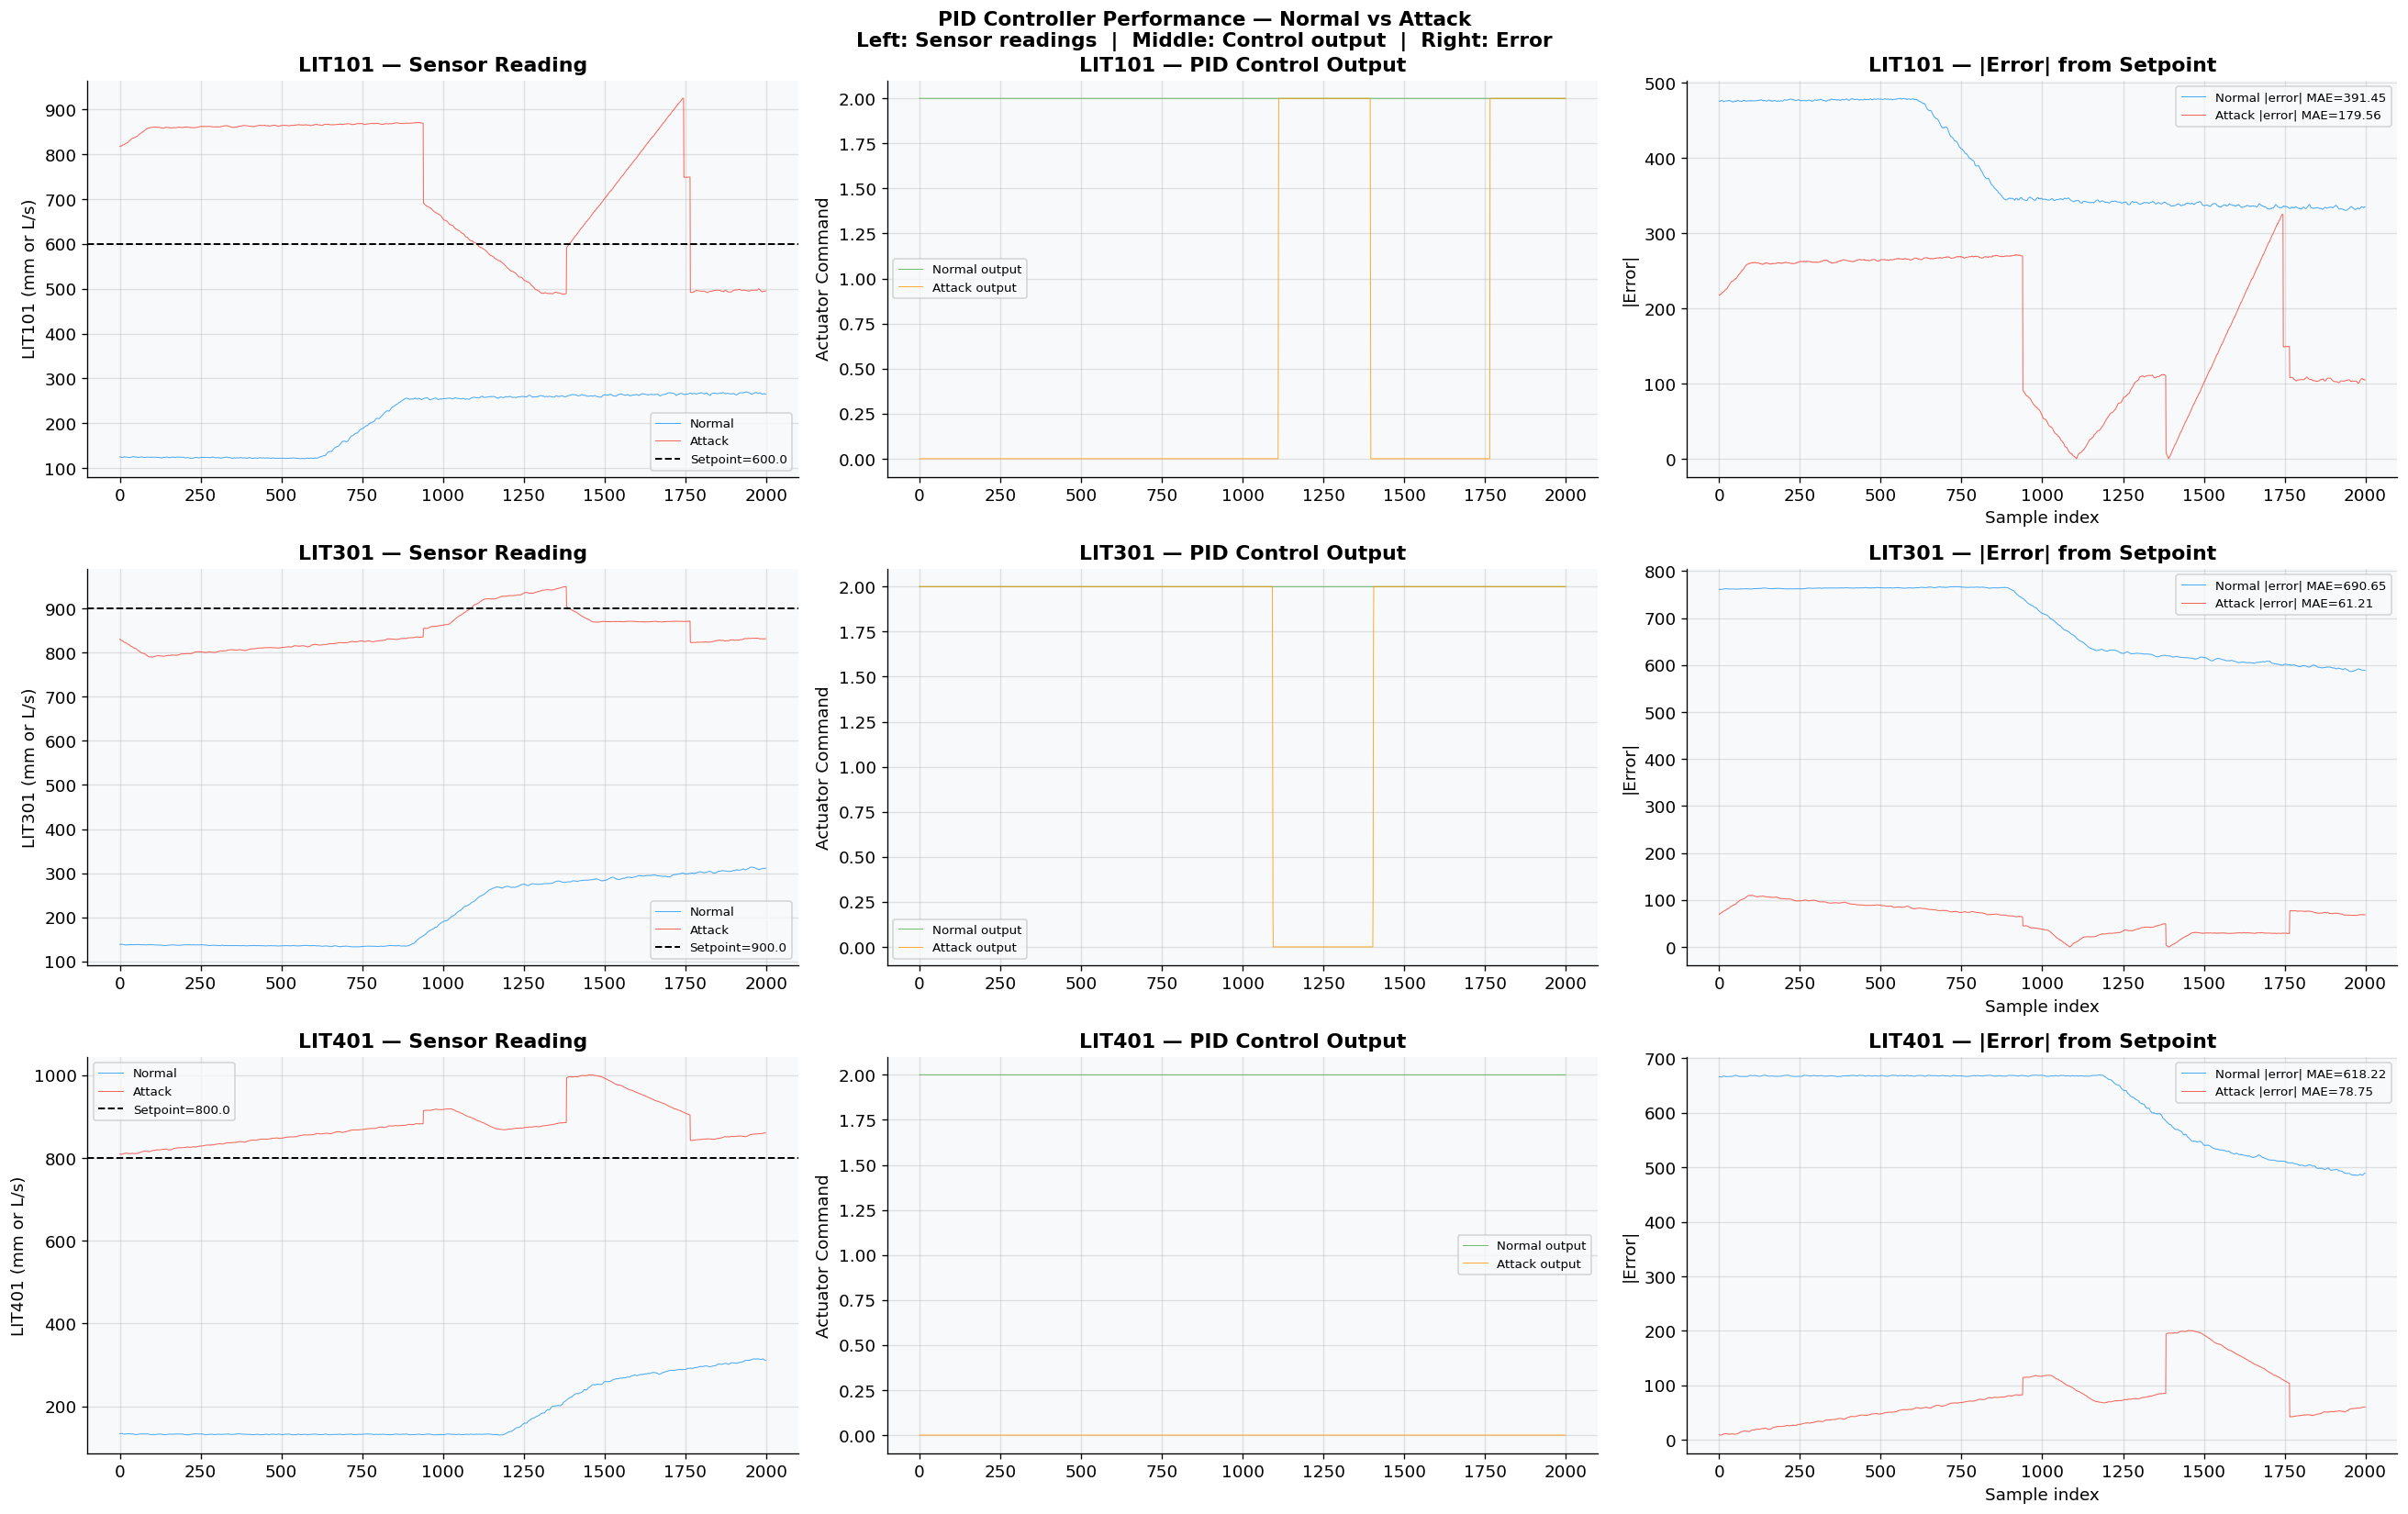

 Saved: 09_pid_normal_vs_attack.png


In [5]:
#   CELL 5 — Visualise PID control: Normal vs Attack              

sensors_to_plot = ['LIT101', 'LIT301', 'LIT401']
N_PLOT          = 2000

fig, axes = plt.subplots(3, 3, figsize=(22, 14))
fig.suptitle('PID Controller Performance — Normal vs Attack\n'
             'Left: Sensor readings  |  Middle: Control output  |  Right: Error',
             fontsize=13, fontweight='bold')

for row, sensor in enumerate(sensors_to_plot):
    sp     = SETPOINTS[sensor]
    n_data = df_normal[sensor].values[:N_PLOT]
    a_data = df_attack[sensor].values[:N_PLOT]
    n_out  = pid_results_normal[sensor]['output'][:N_PLOT]
    a_out  = pid_results_attack[sensor]['output'][:N_PLOT]
    n_err  = pid_results_normal[sensor]['error'][:N_PLOT]
    a_err  = pid_results_attack[sensor]['error'][:N_PLOT]
    x      = np.arange(N_PLOT)

    # Panel 1: Sensor readings vs setpoint
    axes[row][0].plot(x, n_data, color='#2196F3', linewidth=0.6,
                       label='Normal', alpha=0.8)
    axes[row][0].plot(x, a_data, color='#F44336', linewidth=0.6,
                       label='Attack', alpha=0.8)
    axes[row][0].axhline(sp, color='black', linestyle='--',
                          linewidth=1.2, label=f'Setpoint={sp}')
    axes[row][0].set_title(f'{sensor} — Sensor Reading', fontweight='bold')
    axes[row][0].set_ylabel(f'{sensor} (mm or L/s)')
    axes[row][0].legend(fontsize=8)

    # Panel 2: Control output
    axes[row][1].plot(x, n_out, color='#4CAF50', linewidth=0.6,
                       label='Normal output', alpha=0.8)
    axes[row][1].plot(x, a_out, color='#FF9800', linewidth=0.6,
                       label='Attack output', alpha=0.8)
    axes[row][1].set_title(f'{sensor} — PID Control Output', fontweight='bold')
    axes[row][1].set_ylabel('Actuator Command')
    axes[row][1].legend(fontsize=8)

    # Panel 3: Control error
    axes[row][2].plot(x, np.abs(n_err), color='#2196F3', linewidth=0.6,
                       label=f'Normal |error| MAE={np.mean(np.abs(n_err)):.2f}',
                       alpha=0.8)
    axes[row][2].plot(x, np.abs(a_err), color='#F44336', linewidth=0.6,
                       label=f'Attack |error| MAE={np.mean(np.abs(a_err)):.2f}',
                       alpha=0.8)
    axes[row][2].set_title(f'{sensor} — |Error| from Setpoint', fontweight='bold')
    axes[row][2].set_ylabel('|Error|')
    axes[row][2].legend(fontsize=8)
    axes[row][2].set_xlabel('Sample index')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/09_pid_normal_vs_attack.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 09_pid_normal_vs_attack.png')

In [6]:
#  CELL 6 — Reinforcement Learning Environment                   
#  Custom Gymnasium environment wrapping the SWaT control loop   

import gymnasium as gym
from gymnasium import spaces

class SWaTControlEnv(gym.Env):
    """
    Custom Gymnasium environment simulating the SWaT water treatment
    control loop. The RL agent learns to control tank levels by
    adjusting valve and pump commands.

    State  : [current_level, setpoint, error, prev_error, timestep_norm]
    Action : continuous actuator command in [0, 2]
    Reward : negative absolute error — agent minimises deviation from setpoint
    """

    metadata = {'render_modes': []}

    def __init__(self, sensor_data, setpoint, sensor_name='LIT101'):
        super().__init__()

        self.sensor_data  = sensor_data.astype(np.float32)
        self.setpoint     = float(setpoint)
        self.sensor_name  = sensor_name
        self.n_steps      = len(sensor_data)

        # Observation: [level, setpoint, error, prev_error, time_norm]
        self.observation_space = spaces.Box(
            low   = np.array([-1e6, -1e6, -1e6, -1e6, 0.0], dtype=np.float32),
            high  = np.array([ 1e6,  1e6,  1e6,  1e6, 1.0], dtype=np.float32),
            dtype = np.float32
        )

        # Action: actuator command [0=off, 1=normal, 2=full open]
        self.action_space = spaces.Box(
            low   = np.array([0.0], dtype=np.float32),
            high  = np.array([2.0], dtype=np.float32),
            dtype = np.float32
        )

        self.current_step = 0
        self.prev_error   = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.prev_error   = 0.0
        obs = self._get_obs()
        return obs, {}

    def step(self, action):
        action        = float(np.clip(action[0], 0.0, 2.0))
        level         = float(self.sensor_data[self.current_step])
        error         = self.setpoint - level
        abs_error     = abs(error)

        # Reward: penalise large errors, reward staying near setpoint
        # Bonus for reducing error vs previous step
        reward = -abs_error / 100.0
        if abs_error < abs(self.prev_error):
            reward += 0.1   # small bonus for improving

        self.prev_error    = error
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 1
        truncated  = False

        obs = self._get_obs()
        return obs, reward, terminated, truncated, {}

    def _get_obs(self):
        level      = float(self.sensor_data[self.current_step])
        error      = self.setpoint - level
        time_norm  = self.current_step / self.n_steps
        return np.array(
            [level, self.setpoint, error, self.prev_error, time_norm],
            dtype=np.float32
        )


# ── Test environment ─────────────────────────────────────────────
test_env = SWaTControlEnv(
    sensor_data  = df_normal['LIT101'].values[:10000],
    setpoint     = SETPOINTS['LIT101'],
    sensor_name  = 'LIT101'
)
obs, _ = test_env.reset()
print(' SWaTControlEnv created and tested')
print(f'  Observation space : {test_env.observation_space}')
print(f'  Action space      : {test_env.action_space}')
print(f'  Sample obs        : {obs}')
print(f'  Steps in env      : {test_env.n_steps:,}')

 SWaTControlEnv created and tested
  Observation space : Box([-1000000. -1000000. -1000000. -1000000.        0.], [1.e+06 1.e+06 1.e+06 1.e+06 1.e+00], (5,), float32)
  Action space      : Box(0.0, 2.0, (1,), float32)
  Sample obs        : [124.3135 600.     475.6865   0.       0.    ]
  Steps in env      : 10,000


In [7]:
#   CELL 7 — Train PPO RL Agent                                   
#   PPO learns optimal control policy from normal SWaT data       

from stable_baselines3           import PPO
from stable_baselines3.common.env_util import make_vec_env

print('Training PPO RL agents...')
print()

rl_agents   = {}
rl_results  = {}

# Train one RL agent per controlled variable
TRAIN_SENSORS = ['LIT101', 'LIT301', 'LIT401']

for sensor in TRAIN_SENSORS:
    if sensor not in df_normal.columns:
        continue

    sp         = SETPOINTS[sensor]
    train_data = df_normal[sensor].values[:50_000]  # 50K normal rows

    print(f'\nTraining PPO for {sensor} (setpoint={sp})...')

    # Create environment
    env = SWaTControlEnv(
        sensor_data = train_data,
        setpoint    = sp,
        sensor_name = sensor
    )

    # Train PPO agent
    model = PPO(
        policy             = 'MlpPolicy',
        env                = env,
        learning_rate      = 3e-4,
        n_steps            = 1024,
        batch_size         = 64,
        n_epochs           = 10,
        gamma              = 0.99,
        gae_lambda         = 0.95,
        clip_range         = 0.2,
        verbose            = 0,
        seed               = 42,
    )
    model.learn(total_timesteps=50_000)

    # Evaluate on normal data
    env.reset()
    obs, _     = env.reset()
    outputs    = []
    rewards    = []
    done       = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        outputs.append(float(action[0]))
        rewards.append(reward)
        done = terminated or truncated

    mean_reward = np.mean(rewards)
    rl_agents[sensor]  = model
    rl_results[sensor] = {
        'mean_reward' : mean_reward,
        'outputs'     : np.array(outputs),
        'n_trained'   : len(train_data),
    }

    # Save model
    model_path = f'{OUT}/models/ppo_{sensor}'
    model.save(model_path)
    print(f'   Trained   | Mean reward: {mean_reward:.4f}')
    print(f'   Saved     → {model_path}.zip')

print('\n All PPO agents trained')

2026-04-14 18:00:03.853479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776189604.096055      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776189604.157854      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776189604.749236      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776189604.749284      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776189604.749287      16 computation_placer.cc:177] computation placer alr

Training PPO RL agents...


Training PPO for LIT101 (setpoint=600.0)...
   Trained   | Mean reward: -1.4102
   Saved     → /kaggle/working//models/ppo_LIT101.zip

Training PPO for LIT301 (setpoint=900.0)...
   Trained   | Mean reward: -1.2047
   Saved     → /kaggle/working//models/ppo_LIT301.zip

Training PPO for LIT401 (setpoint=800.0)...
   Trained   | Mean reward: -1.3303
   Saved     → /kaggle/working//models/ppo_LIT401.zip

 All PPO agents trained


In [8]:
#   CELL 8 — Adversarial Injection Experiments                    
#   Replay attack sensor values → measure control loop deviation  
#   This produces the "control deviation" feature for Phase 3     

print('Running adversarial injection experiments...')
print()

adversarial_results = {}

for sensor in TRAIN_SENSORS:
    if sensor not in rl_agents or sensor not in df_attack.columns:
        continue

    sp          = SETPOINTS[sensor]
    model       = rl_agents[sensor]
    pid         = pid_controllers[sensor]

    # ── Normal operation baseline ────────────────────────────────
    normal_data  = df_normal[sensor].values[:5000]
    pid.reset()
    pid_out_n, pid_err_n = pid.run_on_series(normal_data, sp)

    env_n        = SWaTControlEnv(normal_data, sp, sensor)
    obs, _       = env_n.reset()
    rl_out_n     = []
    done         = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env_n.step(action)
        rl_out_n.append(float(action[0]))
        done = terminated or truncated
    rl_out_n = np.array(rl_out_n)

    # ── Attack injection ─────────────────────────────────────────
    attack_data  = df_attack[sensor].values[:5000]
    pid.reset()
    pid_out_a, pid_err_a = pid.run_on_series(attack_data, sp)

    env_a        = SWaTControlEnv(attack_data, sp, sensor)
    obs, _       = env_a.reset()
    rl_out_a     = []
    done         = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env_a.step(action)
        rl_out_a.append(float(action[0]))
        done = terminated or truncated
    rl_out_a = np.array(rl_out_a)

    # ── Compute deviation metrics ────────────────────────────────
    min_len     = min(len(pid_out_n), len(pid_out_a),
                      len(rl_out_n),  len(rl_out_a))

    pid_dev     = np.abs(pid_out_a[:min_len] - pid_out_n[:min_len])
    rl_dev      = np.abs(rl_out_a[:min_len]  - rl_out_n[:min_len])
    error_dev   = np.abs(pid_err_a[:min_len] - pid_err_n[:min_len])

    adversarial_results[sensor] = {
        'pid_deviation_mean'  : float(np.mean(pid_dev)),
        'pid_deviation_max'   : float(np.max(pid_dev)),
        'rl_deviation_mean'   : float(np.mean(rl_dev)),
        'rl_deviation_max'    : float(np.max(rl_dev)),
        'error_deviation_mean': float(np.mean(error_dev)),
        'pid_out_normal'      : pid_out_n[:min_len],
        'pid_out_attack'      : pid_out_a[:min_len],
        'rl_out_normal'       : rl_out_n[:min_len],
        'rl_out_attack'       : rl_out_a[:min_len],
        'pid_err_normal'      : pid_err_n[:min_len],
        'pid_err_attack'      : pid_err_a[:min_len],
    }

    print(f'\n  {sensor}')
    print(f'    PID deviation (attack vs normal) : '
          f'{np.mean(pid_dev):.4f} (mean)  {np.max(pid_dev):.4f} (max)')
    print(f'    RL  deviation (attack vs normal) : '
          f'{np.mean(rl_dev):.4f} (mean)  {np.max(rl_dev):.4f} (max)')
    print(f'    Error deviation                  : '
          f'{np.mean(error_dev):.4f}')

print('\n Adversarial injection experiments complete')

Running adversarial injection experiments...


  LIT101
    PID deviation (attack vs normal) : 0.7995 (mean)  2.0000 (max)
    RL  deviation (attack vs normal) : 0.0014 (mean)  0.0097 (max)
    Error deviation                  : 367.6363

  LIT301
    PID deviation (attack vs normal) : 1.0994 (mean)  2.0000 (max)
    RL  deviation (attack vs normal) : 0.1592 (mean)  0.2607 (max)
    Error deviation                  : 588.6303

  LIT401
    PID deviation (attack vs normal) : 1.5699 (mean)  2.0000 (max)
    RL  deviation (attack vs normal) : 0.2425 (mean)  0.3857 (max)
    Error deviation                  : 524.5778

 Adversarial injection experiments complete


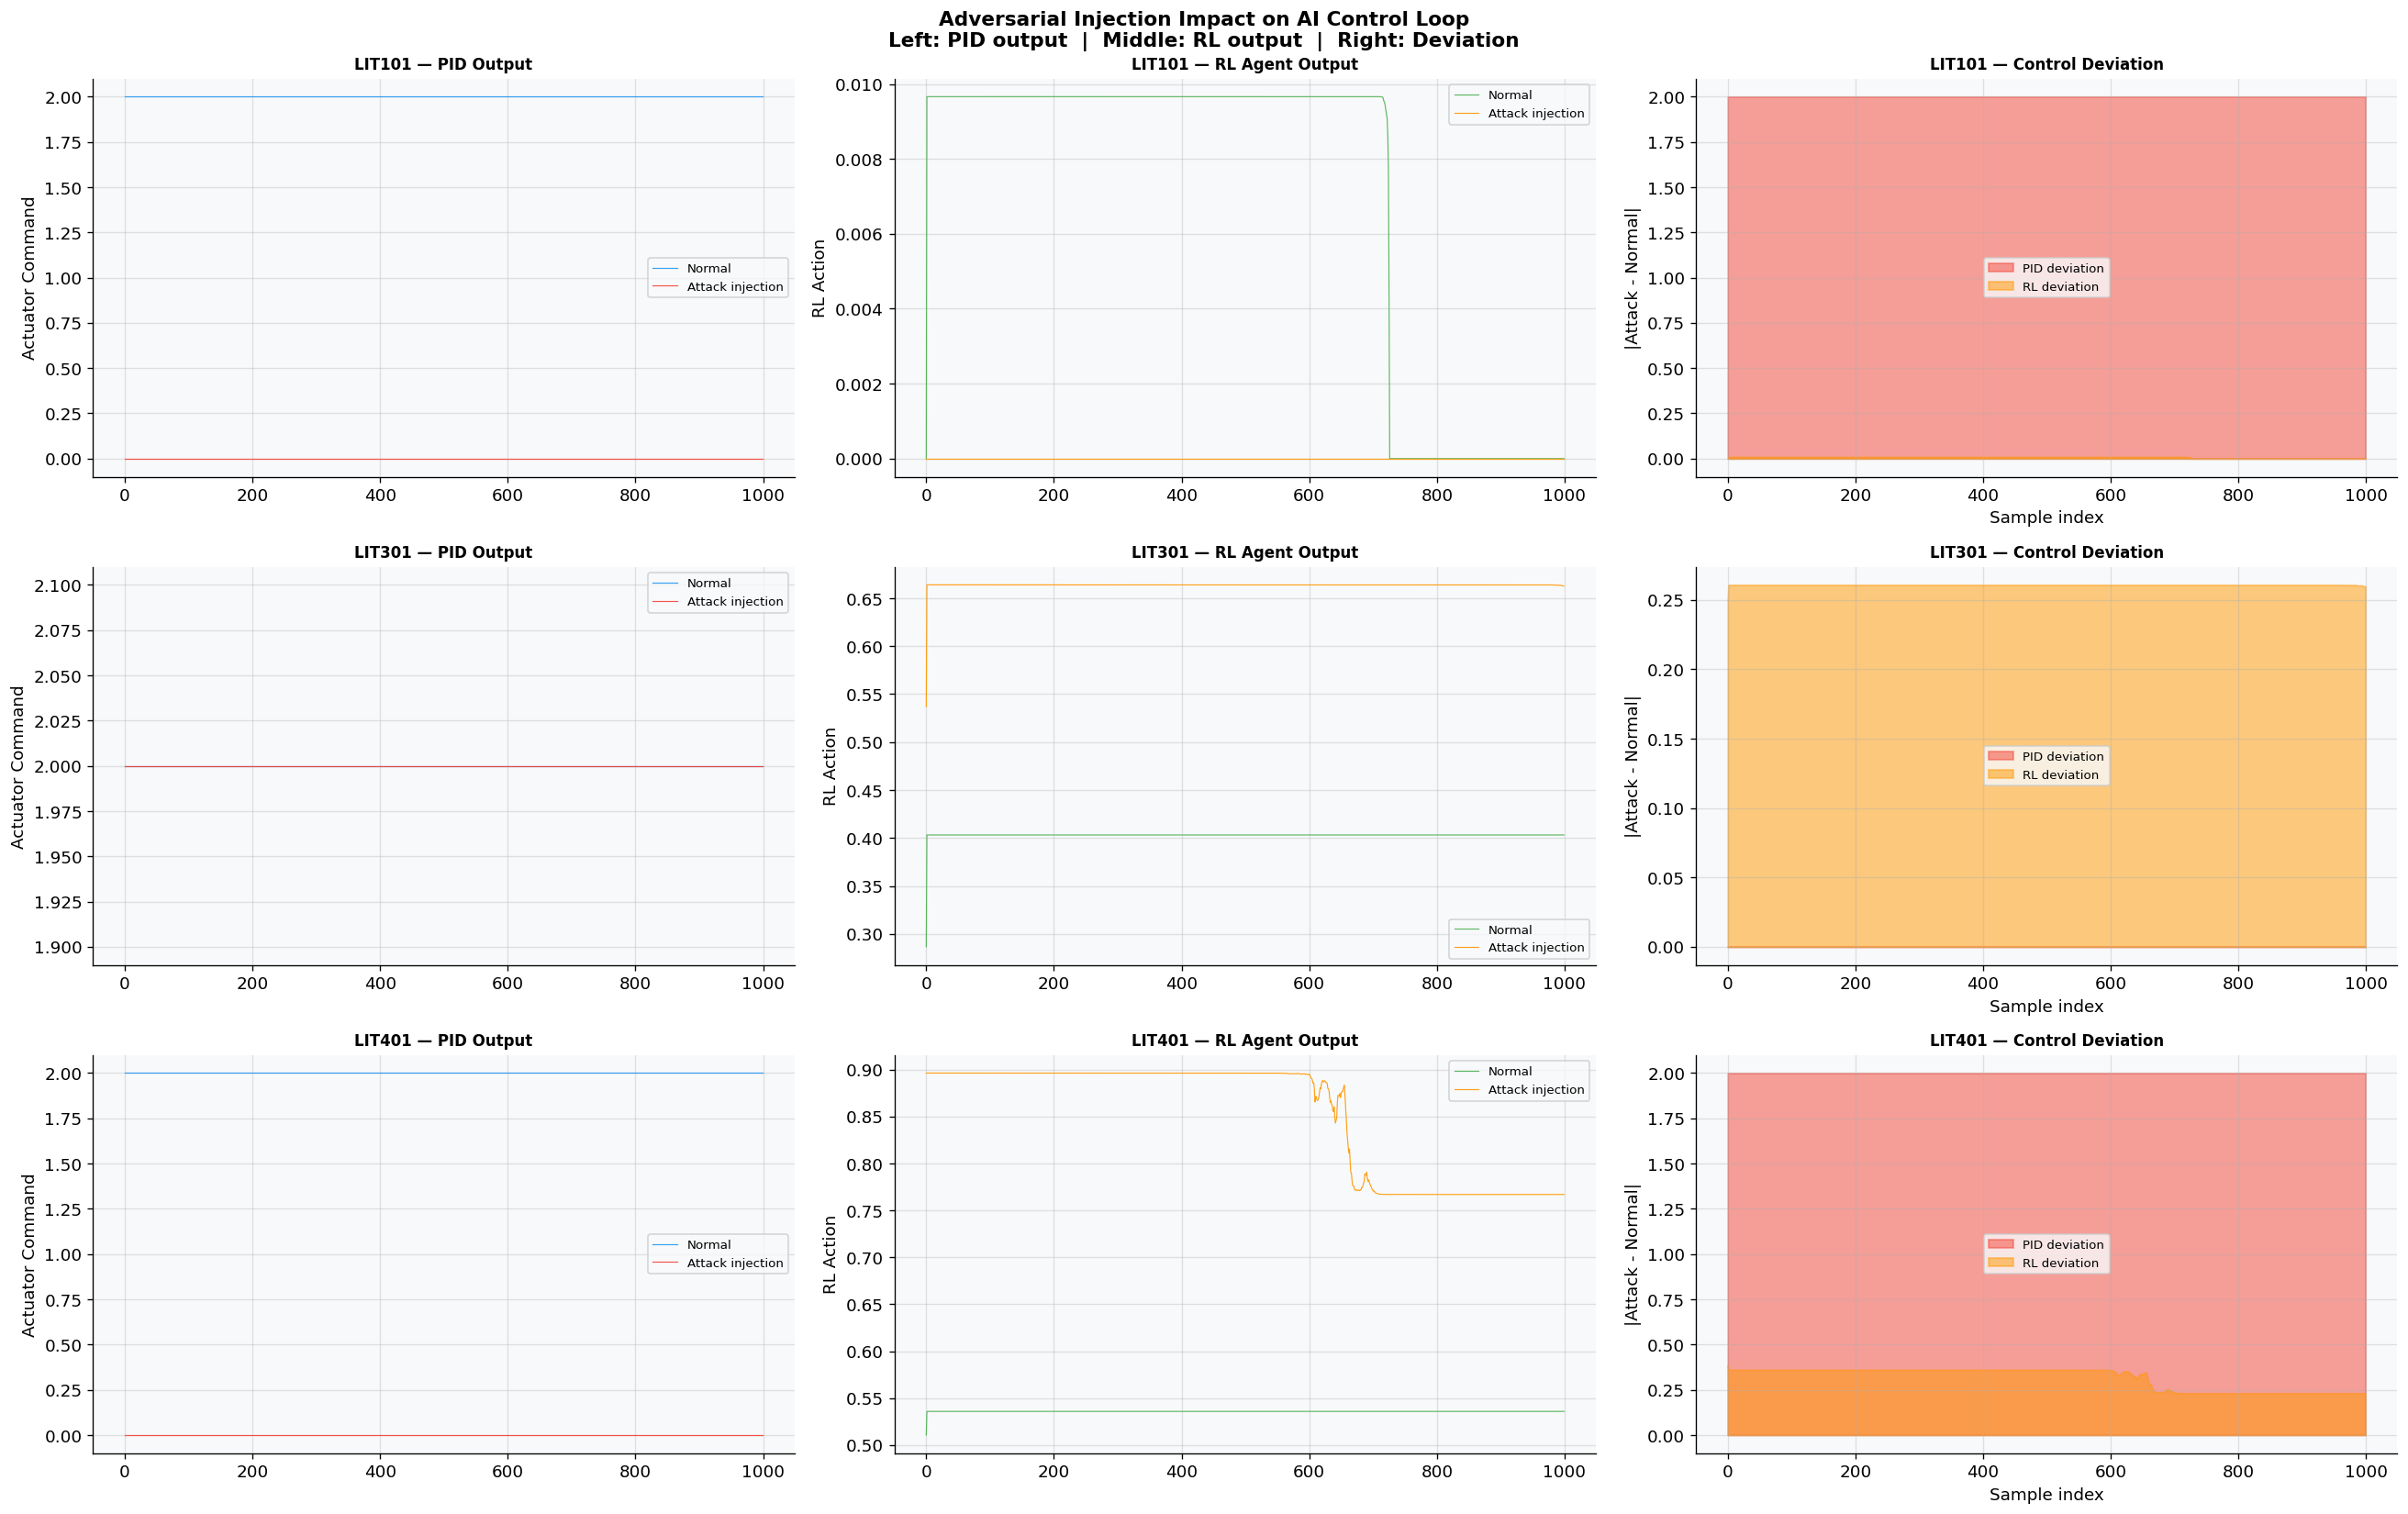

 Saved: 10_adversarial_impact.png


In [9]:
#  CELL 9 — Visualise adversarial impact on control loop        

N_PLOT = 1000
fig, axes = plt.subplots(3, 3, figsize=(22, 14))
fig.suptitle('Adversarial Injection Impact on AI Control Loop\n'
             'Left: PID output  |  Middle: RL output  |  Right: Deviation',
             fontsize=13, fontweight='bold')

for row, sensor in enumerate(TRAIN_SENSORS):
    if sensor not in adversarial_results:
        continue

    res   = adversarial_results[sensor]
    x     = np.arange(min(N_PLOT, len(res['pid_out_normal'])))

    # Panel 1: PID output normal vs attack
    axes[row][0].plot(x, res['pid_out_normal'][:N_PLOT],
                       color='#2196F3', linewidth=0.7,
                       label='Normal', alpha=0.9)
    axes[row][0].plot(x, res['pid_out_attack'][:N_PLOT],
                       color='#F44336', linewidth=0.7,
                       label='Attack injection', alpha=0.9)
    axes[row][0].set_title(f'{sensor} — PID Output',
                            fontweight='bold', fontsize=10)
    axes[row][0].set_ylabel('Actuator Command')
    axes[row][0].legend(fontsize=8)

    # Panel 2: RL output normal vs attack
    axes[row][1].plot(x, res['rl_out_normal'][:len(x)],
                       color='#4CAF50', linewidth=0.7,
                       label='Normal', alpha=0.9)
    axes[row][1].plot(x, res['rl_out_attack'][:len(x)],
                       color='#FF9800', linewidth=0.7,
                       label='Attack injection', alpha=0.9)
    axes[row][1].set_title(f'{sensor} — RL Agent Output',
                            fontweight='bold', fontsize=10)
    axes[row][1].set_ylabel('RL Action')
    axes[row][1].legend(fontsize=8)

    # Panel 3: deviation
    pid_dev = np.abs(res['pid_out_attack'][:len(x)] -
                     res['pid_out_normal'][:len(x)])
    rl_dev  = np.abs(res['rl_out_attack'][:len(x)] -
                     res['rl_out_normal'][:len(x)])

    axes[row][2].fill_between(x, pid_dev, alpha=0.5,
                               color='#F44336', label='PID deviation')
    axes[row][2].fill_between(x, rl_dev,  alpha=0.5,
                               color='#FF9800', label='RL deviation')
    axes[row][2].set_title(f'{sensor} — Control Deviation',
                            fontweight='bold', fontsize=10)
    axes[row][2].set_ylabel('|Attack - Normal|')
    axes[row][2].legend(fontsize=8)
    axes[row][2].set_xlabel('Sample index')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/10_adversarial_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 10_adversarial_impact.png')

In [10]:
#   CELL 10 — Build control deviation feature dataset             
#   This is the KEY output of Phase 2A:                          
#   A new feature column per sensor showing how badly the        
#   AI control loop was disrupted — fed into Phase 3 models      

print('Building control deviation feature dataset...')

# Run PID on FULL dataset (normal + attack) for all sensors
control_deviation_df = pd.DataFrame(index=df.index)
control_deviation_df['binary_label'] = df['binary_label'].values
control_deviation_df['Timestamp']    = df['Timestamp'].values

for sensor, pid in pid_controllers.items():
    if sensor not in df.columns:
        continue

    sp             = SETPOINTS[sensor]
    sensor_values  = df[sensor].values

    pid.reset()
    pid_out, pid_err = pid.run_on_series(sensor_values, sp)

    # Control deviation features
    control_deviation_df[f'{sensor}_pid_output']      = pid_out
    control_deviation_df[f'{sensor}_pid_error']       = pid_err
    control_deviation_df[f'{sensor}_pid_error_abs']   = np.abs(pid_err)

    # Rolling deviation — captures sustained disruption
    control_deviation_df[f'{sensor}_pid_error_roll10'] = (
        pd.Series(np.abs(pid_err))
        .rolling(10, min_periods=1)
        .mean()
        .values
    )

print(f'   Control deviation shape: {control_deviation_df.shape}')
print(f'   Features created: {list(control_deviation_df.columns)}')

# Summary statistics
print('\nControl deviation statistics:')
for sensor in pid_controllers.keys():
    col = f'{sensor}_pid_error_abs'
    if col not in control_deviation_df.columns:
        continue
    normal_dev = control_deviation_df[control_deviation_df['binary_label']==0][col].mean()
    attack_dev = control_deviation_df[control_deviation_df['binary_label']==1][col].mean()
    print(f'  {sensor:<8}  normal={normal_dev:.4f}  '
          f'attack={attack_dev:.4f}  '
          f'ratio={attack_dev/(normal_dev+1e-9):.2f}x worse')

Building control deviation feature dataset...
   Control deviation shape: (944919, 26)
   Features created: ['binary_label', 'Timestamp', 'LIT101_pid_output', 'LIT101_pid_error', 'LIT101_pid_error_abs', 'LIT101_pid_error_roll10', 'LIT301_pid_output', 'LIT301_pid_error', 'LIT301_pid_error_abs', 'LIT301_pid_error_roll10', 'LIT401_pid_output', 'LIT401_pid_error', 'LIT401_pid_error_abs', 'LIT401_pid_error_roll10', 'FIT101_pid_output', 'FIT101_pid_error', 'FIT101_pid_error_abs', 'FIT101_pid_error_roll10', 'FIT201_pid_output', 'FIT201_pid_error', 'FIT201_pid_error_abs', 'FIT201_pid_error_roll10', 'FIT301_pid_output', 'FIT301_pid_error', 'FIT301_pid_error_abs', 'FIT301_pid_error_roll10']

Control deviation statistics:
  LIT101    normal=103.8857  attack=173.9294  ratio=1.67x worse
  LIT301    normal=67.9775  attack=109.3119  ratio=1.61x worse
  LIT401    normal=99.6828  attack=372.0493  ratio=3.73x worse
  FIT101    normal=1.0080  attack=1.4910  ratio=1.48x worse
  FIT201    normal=0.9100  at

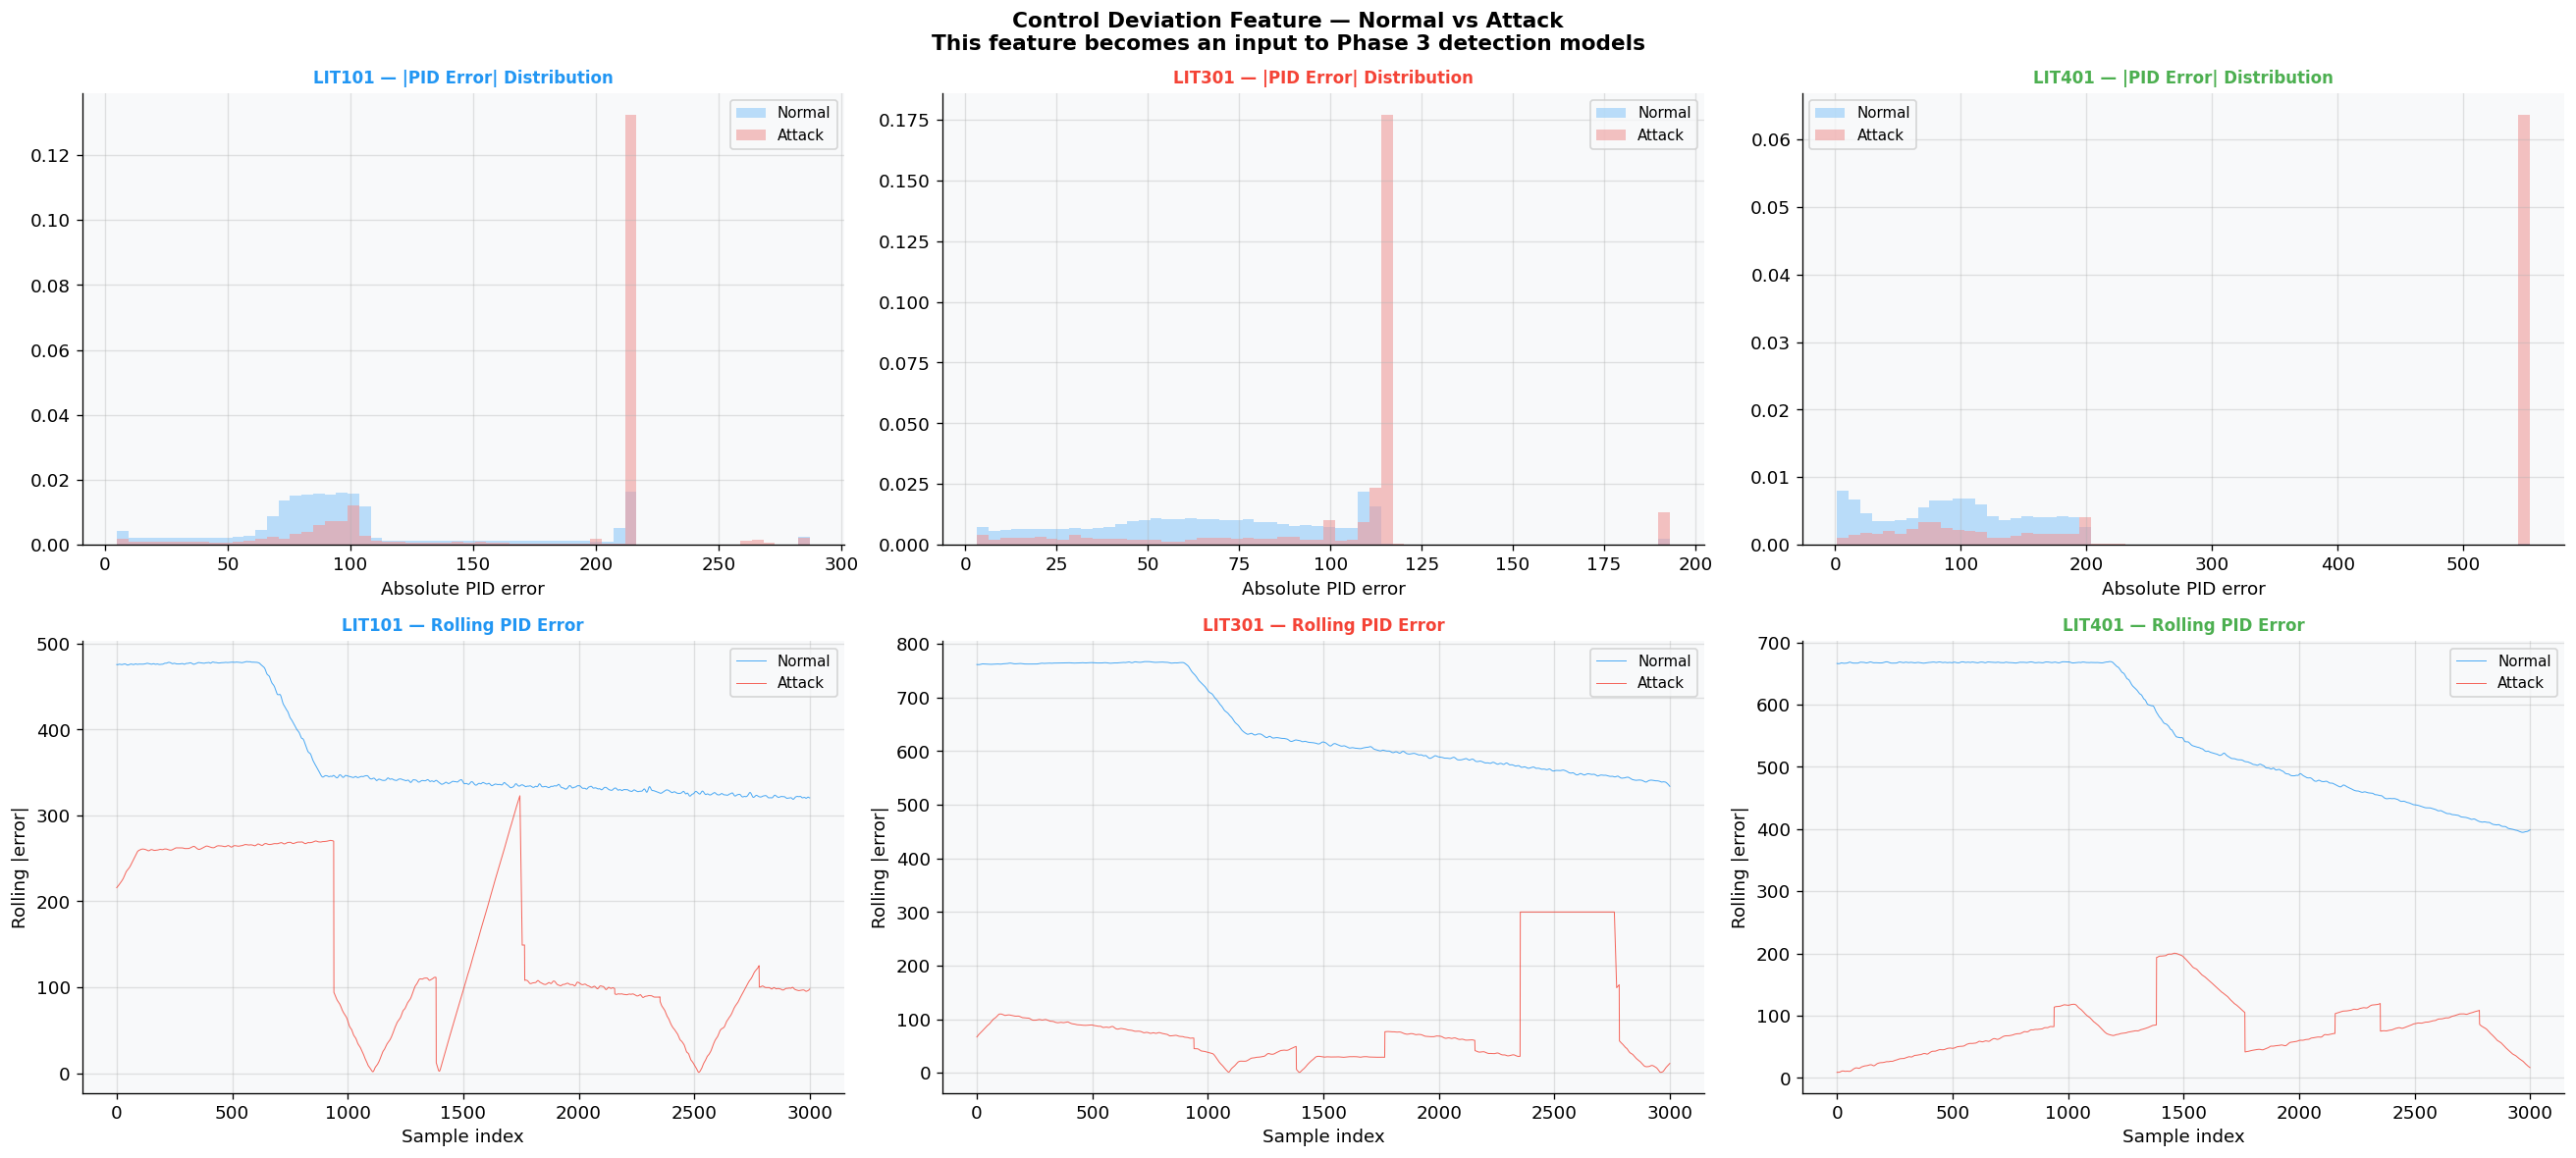

 Saved: 11_control_deviation_feature.png


In [11]:
#   CELL 11 — Visualise control deviation feature                

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle('Control Deviation Feature — Normal vs Attack\n'
             'This feature becomes an input to Phase 3 detection models',
             fontsize=13, fontweight='bold')

COLORS = ['#2196F3', '#F44336', '#4CAF50']

for idx, sensor in enumerate(TRAIN_SENSORS):
    col    = f'{sensor}_pid_error_abs'
    col_r  = f'{sensor}_pid_error_roll10'
    if col not in control_deviation_df.columns:
        continue

    color  = COLORS[idx % len(COLORS)]
    data_n = control_deviation_df[control_deviation_df['binary_label']==0][col].values
    data_a = control_deviation_df[control_deviation_df['binary_label']==1][col].values

    # Row 1: Distribution comparison
    lo = np.percentile(np.concatenate([data_n, data_a]), 1)
    hi = np.percentile(np.concatenate([data_n, data_a]), 99)
    axes[0][idx].hist(np.clip(data_n, lo, hi), bins=60, alpha=0.6,
                       color='#90CAF9', label='Normal', density=True)
    axes[0][idx].hist(np.clip(data_a, lo, hi), bins=60, alpha=0.6,
                       color='#EF9A9A', label='Attack', density=True)
    axes[0][idx].set_title(f'{sensor} — |PID Error| Distribution',
                            fontweight='bold', fontsize=10, color=color)
    axes[0][idx].set_xlabel('Absolute PID error')
    axes[0][idx].legend(fontsize=9)

    # Row 2: Rolling error over time
    roll_n = control_deviation_df[
        control_deviation_df['binary_label']==0][col_r].values[:3000]
    roll_a = control_deviation_df[
        control_deviation_df['binary_label']==1][col_r].values[:3000]
    axes[1][idx].plot(np.arange(len(roll_n)), roll_n,
                       color='#2196F3', linewidth=0.6, alpha=0.8,
                       label='Normal')
    axes[1][idx].plot(np.arange(len(roll_a)), roll_a,
                       color='#F44336', linewidth=0.6, alpha=0.8,
                       label='Attack')
    axes[1][idx].set_title(f'{sensor} — Rolling PID Error',
                            fontweight='bold', fontsize=10, color=color)
    axes[1][idx].set_xlabel('Sample index')
    axes[1][idx].set_ylabel('Rolling |error|')
    axes[1][idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/figures/11_control_deviation_feature.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: 11_control_deviation_feature.png')

In [12]:
#  CELL 12 — Save all Phase 2A outputs                          

P = f'{OUT}/processed'

# 1. Control deviation feature dataset
control_deviation_df.to_csv(f'{P}/control_deviation_features.csv',
                              index=False)
print(f' control_deviation_features.csv  '
      f'→ {control_deviation_df.shape[0]:,} rows × '
      f'{control_deviation_df.shape[1]} cols')

# 2. Adversarial results summary
adv_summary = {}
for sensor, res in adversarial_results.items():
    adv_summary[sensor] = {
        'pid_deviation_mean'   : res['pid_deviation_mean'],
        'pid_deviation_max'    : res['pid_deviation_max'],
        'rl_deviation_mean'    : res['rl_deviation_mean'],
        'rl_deviation_max'     : res['rl_deviation_max'],
        'error_deviation_mean' : res['error_deviation_mean'],
    }
with open(f'{P}/adversarial_results.json', 'w') as f:
    json.dump(adv_summary, f, indent=2)
print(' adversarial_results.json')

# 3. PID baseline results
pid_summary = {}
for sensor in pid_results_normal:
    pid_summary[sensor] = {
        'setpoint'   : SETPOINTS[sensor],
        'normal_mae' : float(pid_results_normal[sensor]['mae']),
        'normal_rmse': float(pid_results_normal[sensor]['rmse']),
        'attack_mae' : float(pid_results_attack[sensor]['mae']),
        'attack_rmse': float(pid_results_attack[sensor]['rmse']),
        'degradation_pct': float(
            (pid_results_attack[sensor]['mae'] -
             pid_results_normal[sensor]['mae']) /
            (pid_results_normal[sensor]['mae'] + 1e-9) * 100
        ),
    }
with open(f'{P}/pid_results.json', 'w') as f:
    json.dump(pid_summary, f, indent=2)
print(' pid_results.json')

# 4. Phase 2A config
p2a_config = {
    'phase'              : '2A',
    'control_sensors'    : CONTROL_SENSORS,
    'control_actuators'  : CONTROL_ACTUATORS,
    'setpoints'          : SETPOINTS,
    'trained_sensors'    : TRAIN_SENSORS,
    'pid_params'         : {
        s: {'kp': pid_controllers[s].kp,
            'ki': pid_controllers[s].ki,
            'kd': pid_controllers[s].kd}
        for s in pid_controllers
    },
    'rl_timesteps'       : 50_000,
    'control_dev_cols'   : [c for c in control_deviation_df.columns
                            if c not in ['binary_label', 'Timestamp']],
}
with open(f'{P}/phase2a_config.json', 'w') as f:
    json.dump(p2a_config, f, indent=2)
print(' phase2a_config.json')

print()
print()
print('  PHASE 2A COMPLETE')
print()
print()
print(f'  PID controllers trained  : {len(pid_controllers)}')
print(f'  RL agents trained        : {len(rl_agents)}')
print(f'  Sensors simulated        : {TRAIN_SENSORS}')
print(f'  Control deviation cols   : '
      f'{len(p2a_config["control_dev_cols"])}')
print(f'  Adversarial experiments  : {len(adversarial_results)}')
print(f'  Figures saved            : 3 (09, 10, 11)')
print(f'  Files saved              : 4')
print()

 control_deviation_features.csv  → 944,919 rows × 26 cols
 adversarial_results.json
 pid_results.json
 phase2a_config.json


  PHASE 2A COMPLETE


  PID controllers trained  : 6
  RL agents trained        : 3
  Sensors simulated        : ['LIT101', 'LIT301', 'LIT401']
  Control deviation cols   : 24
  Adversarial experiments  : 3
  Figures saved            : 3 (09, 10, 11)
  Files saved              : 4

